# Data Augmentation

So far, we've selected a model architecture that vastly improves the model's performance, as it is designed to recognize important features in the images. The validation accuracy is still lagging behind the training accuracy, which is a sign of overfitting: the model is getting confused by things it has not seen before when it tests against the validation dataset.

In order to teach our model to be more robust when looking at new data, we're going to programmatically increase the size and variance in our dataset. This is known as [*data augmentation*](https://link.springer.com/article/10.1186/s40537-019-0197-0), a useful technique for many deep learning applications.

The increase in size gives the model more images to learn from while training. The increase in variance helps the model ignore unimportant features and select only the features that are truly important in classification, allowing it to generalize better.

## Objectives

* Augment the ASL dataset
* Use the augmented data to train an improved model
* Save the well-trained model to disk for use in deployment

## Preparing the Data

As we're in a new notebook, we will load and process our data again.

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import pandas as pd

# Load in our data from CSV files
train_df = pd.read_csv("../data/asl_data/sign_mnist_train.csv")
valid_df = pd.read_csv("../data/asl_data/sign_mnist_valid.csv")

# Separate out our target values
y_train = train_df['label']
y_valid = valid_df['label']
del train_df['label']
del valid_df['label']

# Separate our our image vectors
x_train = train_df.values
x_valid = valid_df.values

# Turn our scalar targets into binary categories
NUM_CLASSES = 24
y_train = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_valid = keras.utils.to_categorical(y_valid, NUM_CLASSES)

# Normalize our image data
x_train = x_train / 255
x_valid = x_valid / 255

# Reshape the image data for the convolutional network
x_train = x_train.reshape(-1,28,28,1)
x_valid = x_valid.reshape(-1,28,28,1)

## Model Creation

We will also need to create our model again. To do this, execute the following cell. You will notice this is the same model architecture as the last section:

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Conv2D,
    MaxPool2D,
    Flatten,
    Dropout,
    BatchNormalization,
)

model = Sequential()
model.add(Conv2D(16, (3, 3), strides=1, padding="same", activation="relu",
                 input_shape=(28, 28, 1)))
model.add(BatchNormalization())
model.add(MaxPool2D((2, 2), strides=2, padding="same"))
model.add(Conv2D(32, (3, 3), strides=1, padding="same", activation="relu"))

model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D((2, 2), strides=2, padding="same"))
model.add(Conv2D(64, (3, 3), strides=1, padding="same", activation="relu"))


model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D((2, 2), strides=2, padding="same"))
model.add(Flatten())
model.add(Dense(units=512, activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(units=NUM_CLASSES, activation="softmax"))


c:\Backup\Python Data Science\AI Projects\signlang_project-main\singlang\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Data Augmentation

Before compiling the model, it's time to set up our data augmentation.

Keras comes with an image augmentation class called `ImageDataGenerator`. We recommend checking out the [documentation here](https://keras.io/api/preprocessing/image/#imagedatagenerator-class). It accepts a series of options for augmenting your data. Later in the course, we'll have you select a proper augmentation strategy. For now, take a look at the options we've selected below, and then execute the cell to create an instance of the class:

In [3]:
# Define paths
MODEL_PATH = "models/3_sl_aug_model.keras"

# Load dataset (Ensure x_train and y_train are properly loaded before this step)
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
) 

Our dataset is pictures of hands signing the alphabet. If we want to use this model to classify hand images later, it's unlikely that those hands are going to be upside-down, but, they might be left-handed. This kind of domain-specific reasoning can help make good decisions for your own deep learning applications.

## Batch Size
Another benefit of the `ImageDataGenerator` is that it [batches](https://machinelearningmastery.com/how-to-control-the-speed-and-stability-of-training-neural-networks-with-gradient-descent-batch-size/) our data so that our model can train on a random sample.

If the model is [truly random](http://sites.utexas.edu/sos/random/), meaning that the data is properly shuffled so it's fair like a deck of cards, then our sample can do a good job of representing all of our data even though it is a tiny fraction of the population. For each step of the training, the model will be dealt a new batch.

In practice, a batch size of 32 and 64 does well.

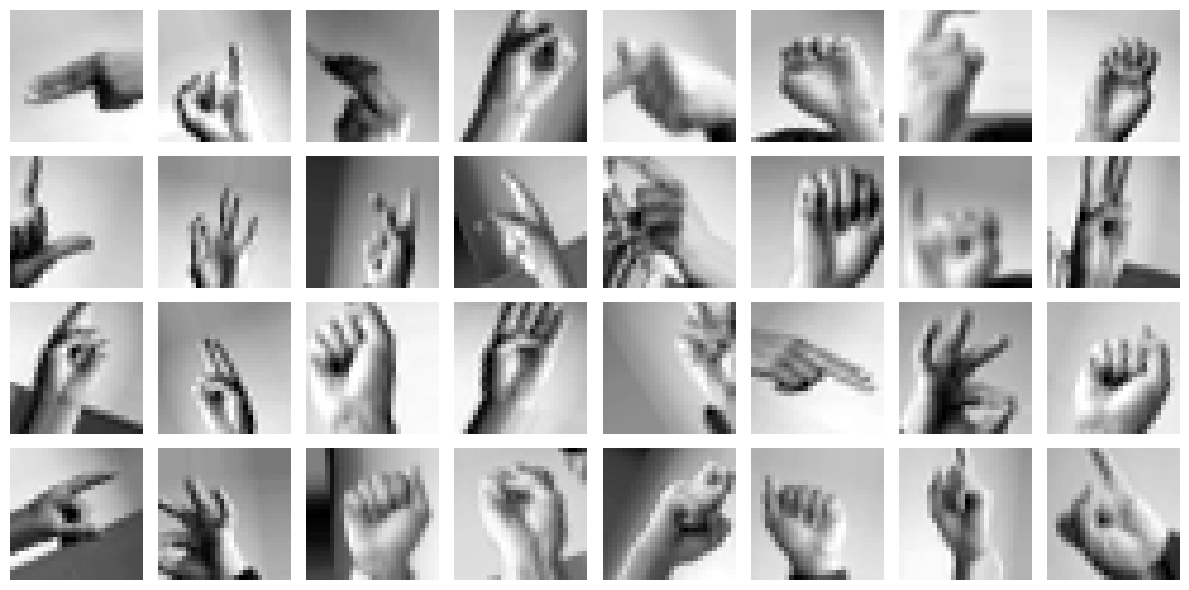

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming datagen, x_train, and y_train are already defined
batch_size = 32

# Create an iterator for the augmented images
img_iter = datagen.flow(x_train, y_train, batch_size=batch_size)

# Fetch the next batch correctly
x, y = next(img_iter)  # Corrected from img_iter.next()

# Create a figure with 4 rows and 8 columns (4x8=32 images)
fig, ax = plt.subplots(nrows=4, ncols=8, figsize=(12, 6))  # Adjust size for better visibility

# Loop through batch size and plot images
for i in range(batch_size):
    image = x[i]  # Get image from batch
    ax.flatten()[i].imshow(np.squeeze(image), cmap='gray')  # Display image
    ax.flatten()[i].axis('off')  # Hide axes for better view

plt.tight_layout()  # Adjust layout for better spacing
plt.show()


## Fitting the Data to the Generator

In [5]:
datagen.fit(x_train)

## Compiling the Model

With the data generator instance created and fit to the training data, the model can now be compiled in the same way as our earlier examples:

In [6]:
model.compile(
    loss='categorical_crossentropy',
    metrics=['accuracy'])

## Training with Augmentation

When using an image data generator with Keras, a model trains a bit differently: instead of just passing the `x_train` and `y_train` datasets into the model, we pass the generator in, calling the generator's [flow](https://keras.io/api/preprocessing/image/) method. This causes the images to get augmented live and in memory right before they are passed into the model for training.

Generators can supply an indefinite amount of data, and when we use them to train our data, we need to explicitly set how long we want each epoch to run, or else the epoch will go on indefinitely, with the generator creating an indefinite number of augmented images to provide the model.

We explicitly set how long we want each epoch to run using the `steps_per_epoch` named argument. Because `steps * batch_size = number_of_images_trained in an epoch` a common practice, that we will use here, is to set the number of steps equal to the non-augmented dataset size divided by the batch_size (which has a default value of 32).

Run the following cell to see the results. The training will take longer than before, which makes sense given we are now training on more data than previously:

In [7]:
history = model.fit(
    img_iter,
    epochs=20,  # Ensure epochs is an integer
    steps_per_epoch=len(x_train) // batch_size,  # Use integer division to avoid float issues
    validation_data=(x_valid, y_valid)
)


Epoch 1/20


c:\Backup\Python Data Science\AI Projects\signlang_project-main\singlang\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


857/857 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.2124 - loss: 2.7675 - val_accuracy: 0.7129 - val_loss: 0.8578
Epoch 2/20
  1/857 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.5000 - loss: 1.3275

c:\Backup\Python Data Science\AI Projects\signlang_project-main\singlang\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


857/857 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5000 - loss: 1.3275 - val_accuracy: 0.7305 - val_loss: 0.8086
Epoch 3/20
857/857 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.5516 - loss: 1.3363 - val_accuracy: 0.7500 - val_loss: 0.6473
Epoch 4/20
857/857 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6562 - loss: 1.3508 - val_accuracy: 0.6935 - val_loss: 0.8163
Epoch 5/20
857/857 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.6710 - loss: 0.9857 - val_accuracy: 0.8008 - val_loss: 0.5980
Epoch 6/20
857/857 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7812 - loss: 0.7317 - val_accuracy: 0.6198 - val_loss: 1.3010
Epoch 7/20
857/857 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7337 - loss: 0.8110 - val_accuracy: 0.8840 - val_loss: 0.3434
Epoch 8/20
857/857 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7812 - loss: 0.6233 - val_accuracy: 0.8370 - val_loss: 0.4341
Epoch 9/20
857/857 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.7730 - loss: 0.6994 - val_accuracy: 0.8143 

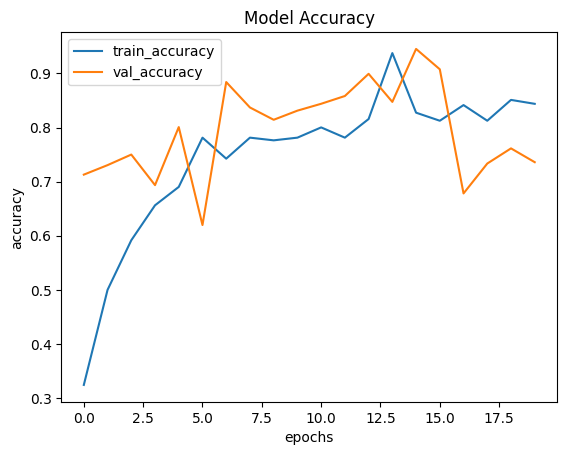

In [8]:
# Ploting the accuracy

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(['train_accuracy', 'val_accuracy'])
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.show()


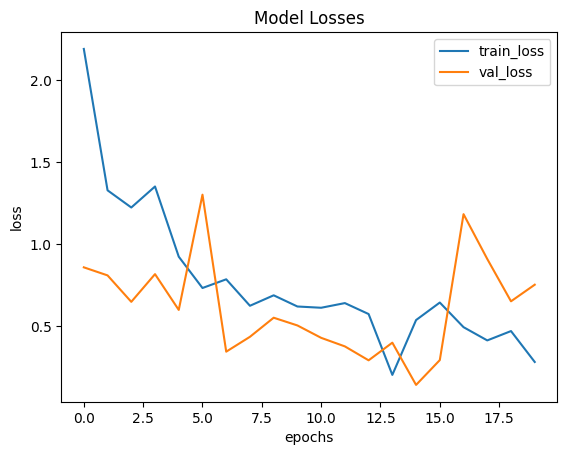

In [9]:
# Ploting the loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Losses")
plt.legend(['train_loss', 'val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()


## Discussion of Results

You will notice that the validation accuracy is higher, and more consistent. This means that our model is no longer overfitting in the way it was; it generalizes better, making better predictions on new data.

## Saving the Model

Now that we have a well-trained model, we will want to deploy it to perform inference on new images.

It is common, once we have a trained model that we are happy with to save it to disk.

Saving the model in Keras is quite easy using the save method. There are different formats that we can save in, but we'll use the default for now. If you'd like, feel free to check out [the documentation](https://www.tensorflow.org/guide/keras/save_and_serialize). In the next notebook, we'll load the model and use it to read new sign language pictures:

In [10]:
model.save('../models/3_sl_aug_model.keras')

### Clear the Memory
Before moving on, please execute the following cell to clear up the GPU memory.

In [ ]:
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

: 